Ths code runs the functions.py file


In [1]:
# importing libraries
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn

import functions as fct

import importlib
importlib.reload(fct)


<module 'functions' from '/Users/kylemcgillivray/Python/Dissertation/Masters-Dissertation/functions.py'>

[ 1.9856812  -2.02184929]


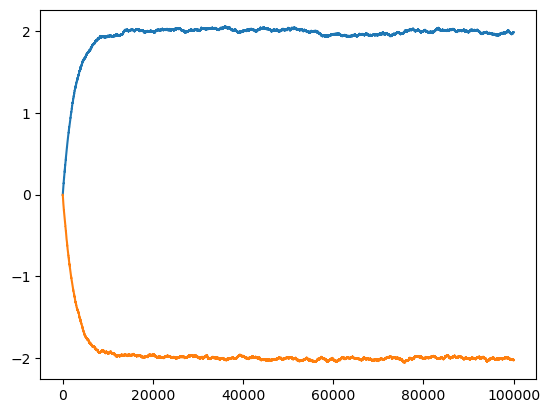

In [19]:
# Trying to get this stochastic gradient descent algo to function.
d = 2
mu_unknown = np.array([2, -2])
sigma_known = np.array([1,1])

N = 100000  # number of data points
# Generate the data for normal
X_data = np.random.normal(mu_unknown, sigma_known, (N, d))

# reasonable parameters
theta_0 = np.zeros(d)
beta = 1e6
lambda_ = 0.001
N_sgld = 100000
t_0 = 0
T = 1

theta_hat, theta_tracker = fct.thetahat_func(X_data = X_data, beta= beta, lambda_= lambda_, 
                          theta_0= theta_0, N_sgld= N_sgld, t_0= t_0, T = T)

print(theta_hat)
plt.plot(theta_tracker)

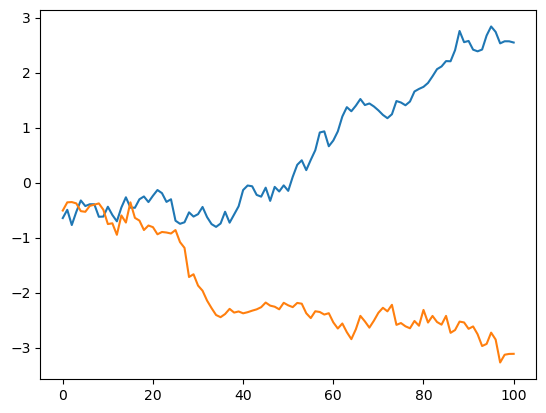

In [20]:
sample, path = fct.euler_maruyama_sample(theta_hat=theta_hat, gamma=0.01, T = 1, d = 2)
sample

plt.plot(path)

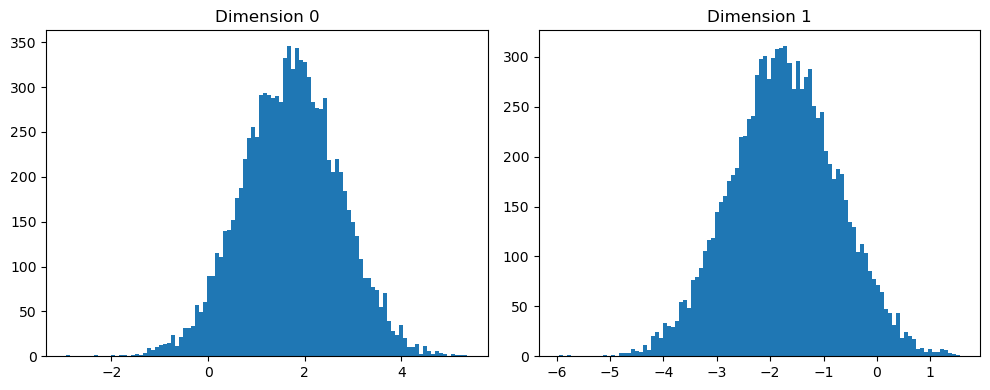

In [21]:
# Now I want to verify the distribution of the samples is in line with what I should expect.
# print(sample)

# N_samples = 100000
N_samples = 10_000
samples = []
for i in range(N_samples):
    sample, path = fct.euler_maruyama_sample(theta_hat=theta_hat, gamma=0.001, T = 1, d = 2)
    samples.append(sample)


samples_arr = np.array(samples) # shape (N_samples, d)

fig, axes = plt.subplots(1, d, figsize=(10, 4))

for i in range(d):
    axes[i].hist(samples_arr[:, i], bins=100)
    axes[i].set_title(f"Dimension {i}")

plt.tight_layout()
plt.show()

iter 0, loss = 4.2996
iter 500, loss = 2.2277
iter 1000, loss = 2.6284
iter 1500, loss = 3.3848
iter 2000, loss = 2.3914
iter 2500, loss = 2.0995
iter 3000, loss = 3.2592
iter 3500, loss = 8.2746
iter 4000, loss = 1.9770
iter 4500, loss = 2.2009
NN sample mean: [ 0.4383544  -0.46614433]
True mu:        [ 0.5 -0.5]


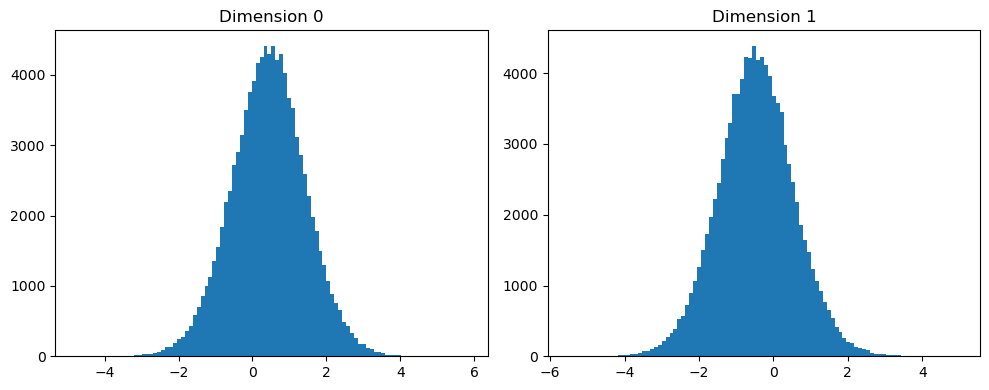

In [5]:
# device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")

d = 2
net = fct.ScoreNet(d=d, D_1=32)

net = fct.train_score_net(net, X_data, t_0=0, T=1, d=d,
                       n_iters=5000, batch_size=256, lr=1e-3, device=device)

samples_nn_arr = fct.euler_maruyama_sample_nn_batch(net, gamma=0.001, T=1, d=d,
                                                  N_samples=100000, device=device)

print("NN sample mean:", samples_nn_arr.mean(axis=0))
print("True mu:       ", mu_unknown)


# Plot the distributions of the samples
fig, axes = plt.subplots(1, d, figsize=(10, 4))

for i in range(d):
    axes[i].hist(samples_nn_arr[:, i], bins=100)
    axes[i].set_title(f"Dimension {i}")

plt.tight_layout()
plt.show()

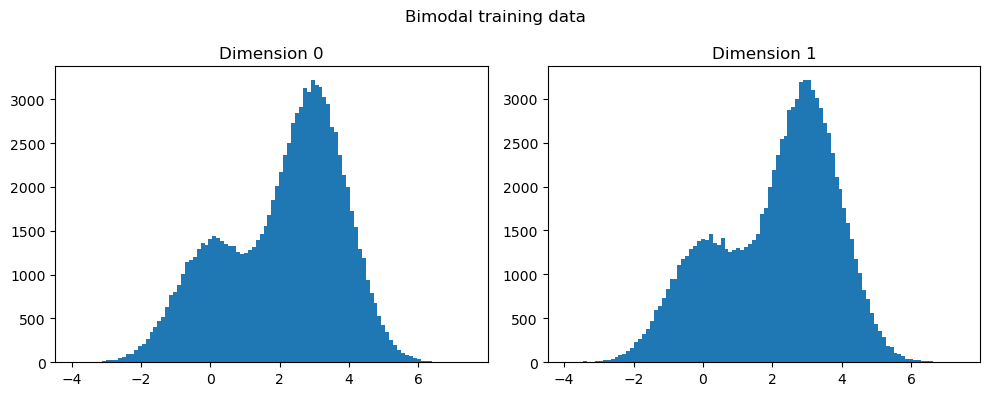

In [35]:
d = 2
mu1 = np.array([3, 3])
mu2 = np.array([0, 0])
weight = 0.7

X_data_bimodal = fct.sample_bimodal_data(N=100000, d=d, mu1=mu1, mu2=mu2, sigma=1.0, weight=weight)

fig, axes = plt.subplots(1, d, figsize=(10, 4))
for i in range(d):
    axes[i].hist(X_data_bimodal[:, i], bins=100)
    axes[i].set_title(f"Dimension {i}")
plt.suptitle("Bimodal training data")
plt.tight_layout()
plt.show()

iter 0, loss = 5.3746
iter 500, loss = 2.0068
iter 1000, loss = 2.5112
iter 1500, loss = 2.3067
iter 2000, loss = 2.6780
iter 2500, loss = 3.1053
iter 3000, loss = 2.7416
iter 3500, loss = 4.2926
iter 4000, loss = 3.6509
iter 4500, loss = 4.6727
iter 5000, loss = 2.8438
iter 5500, loss = 4.0320
iter 6000, loss = 2.8413
iter 6500, loss = 2.7125
iter 7000, loss = 2.5531
iter 7500, loss = 2.6806
iter 8000, loss = 3.8593
iter 8500, loss = 1.7678
iter 9000, loss = 2.6634
iter 9500, loss = 2.0459
NN sample mean:     [1.16698488 1.25781942]
True mixture mean:  [2.1 2.1]


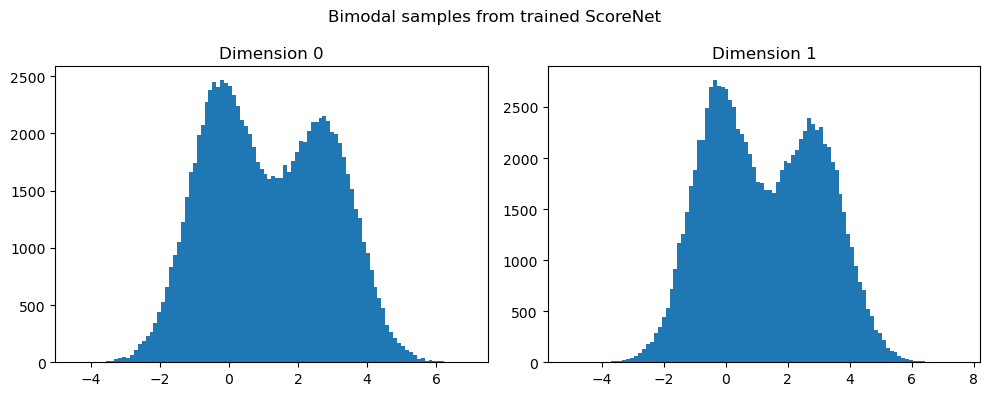

In [36]:
device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")

d = 2
D_1_bimodal = 128

net_bimodal = fct.ScoreNet(d=d, D_1=D_1_bimodal)

net_bimodal = fct.train_score_net(
    net_bimodal, X_data_bimodal,
    t_0=1e-3, T=1, d=d,
    n_iters=10_000, batch_size=512, lr=1e-3,
    device=device
)

samples_bimodal = fct.euler_maruyama_sample_nn_batch(
    net_bimodal, gamma=0.001, T=1, d=d,
    N_samples=100_000, device=device
)

true_mixture_mean = weight * mu1 + (1 - weight) * mu2

print("NN sample mean:    ", samples_bimodal.mean(axis=0))
print("True mixture mean: ", true_mixture_mean)

fig, axes = plt.subplots(1, d, figsize=(10, 4))
for i in range(d):
    axes[i].hist(samples_bimodal[:, i], bins=100)
    axes[i].set_title(f"Dimension {i}")
plt.suptitle("Bimodal samples from trained ScoreNet")
plt.tight_layout()
plt.show()